## 1. The Dataset and Data Cleaning


***Credit to Vivo Vinco on Kaggle for this awesome dataset https://www.kaggle.com/datasets/vivovinco/20222023-football-player-stats

Football (or soccer for NFL fans out there, but please, its football) is the most popular competitive sport in the world.

In a game, there are 11 players for each team on the field.

Midfielders are key positions, as they often take on the role of both attacking and defending. We do not go into details of how midfielders are defined.

It's widely beleived that the best teams wroldwide are located in five major leagues across Europe:
1. Premier League, England
2. La Liga, Spain
3. Bundesliga, Germany
4. Serie A, Italy
5. Ligue 1, France

This dataset examines the game-play stats for all registered midfielders playing in the top five leagues during the 2022-23 season, normalized per 90 minutes.

Each row of the dataset represents an individual player, whereas columns contain the attributes for this player.

A few technical details:
1. Players are capable of playing multiple positions on the field. For example, 'MFFW' in the 'Pos' column means both a  Midfielder and a Forward. We consider all players that played as a 'MF'.
2. It's rare but possible that existing players transfer to different teams during the winter transfer window mid-season. We treat these instances as **distinct** datapoints.

In [1]:
# Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('~/Desktop/mf_data_europe_2023.csv')
print(data.shape)
data.head(5)

(1223, 123)


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,1596,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,770,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
2,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,1799,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
3,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,1165,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4
4,Oliver Abildgaard,DEN,MF,Hellas Verona,Serie A,26,1996,1,0,11,...,0.00,0.00,10.00,0.0,0.0,0.00,10.00,0.00,10.00,0.0


We see that there are 1223 (not necessarily unique) players in this dataset.

A closer examination, however, shows that not all of them are 'useful' datapoints.

In [2]:
data.sort_values(by='Min', ascending=True).head(10)

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
831,Pedro Ortiz,ESP,MF,Sevilla,La Liga,22,2000,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
741,Diego Méndez,ESP,MF,Rayo Vallecano,La Liga,19,2003,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,100.0
713,Marquinhos,BRA,MF,Arsenal,Premier League,19,2003,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673,Saša Luki?,SRB,MF,Fulham,Premier League,26,1996,1,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75,Ayman Azhil,MAR,MF,Leverkusen,Bundesliga,21,2001,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
912,Joshua Quarshie,GER,MF,Hoffenheim,Bundesliga,18,2004,1,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
983,Dikeni Salifou,TOG,MF,Werder Bremen,Bundesliga,19,2003,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
268,Conor Coventry,IRL,MFFW,West Ham,Premier League,22,2000,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
961,Connor Ronan,IRL,MF,Wolves,Premier League,24,1998,1,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
324,Carlos Dominguez,ESP,MF,Celta Vigo,La Liga,22,2001,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In fact, we see that there's a large number of players who do not recieve consistent playing time on the field.

Bin width: 185.90


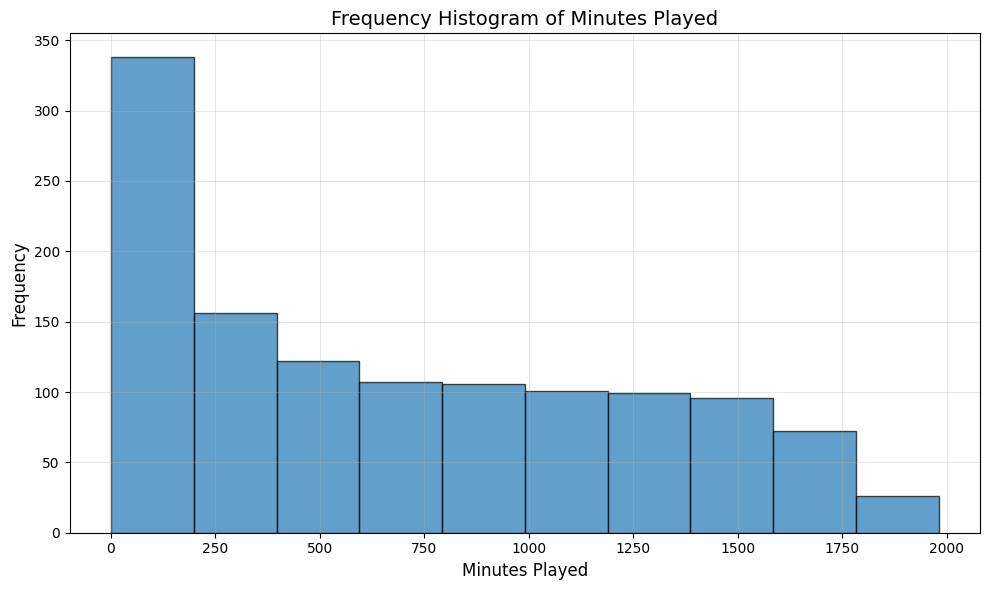

In [3]:
# Plot frequency histogram of 'Min' column
plt.figure(figsize=(10, 6))

Q1_min = data['Min'].quantile(0.25)
Q3_min = data['Min'].quantile(0.75)
IQR_min = Q3_min - Q1_min
bin_width = 2 * IQR_min / (len(data) ** (1/3))
bins = int((data['Min'].max() - data['Min'].min()) / bin_width)

print(f"Bin width: {bin_width:.2f}")

plt.hist(data['Min'], bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Minutes Played', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Histogram of Minutes Played', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


If a player did not play or only played for limited amounts of time, it's almost surely that a majority of their stats would be zero.

To prevent a large amount of zeros from diluting our analysis, we further limit our analysis to players who have enough playing time.

In [4]:
# Remove players who haven't played at least 186 minutes and appeared in at least 5 matches
data = data[(data['MP'] >= 5) & (data['Min'] >= 186)].copy()

Furthermore, some of the stats are highly correlated with others.

For example, G/Sh, or goals per shot, would be highly correlated with the goals scored and the shots taken by a player.

Yet, it does not introduce new information that hasn't been necessarily revealed by goals and or shots already.

There are also some stats that do not apply to midfielders, such as 'PKcon', which are the goals conceded by keepers during penalty kicks.

We would like to remove these stats.

In [5]:
# Some further data cleaning

# Code leagues as integers
def league_to_int(league):
    if league == 'Premier League':
        return 1
    elif league == 'La Liga':
        return 2
    elif league == 'Bundesliga':
        return 3
    elif league == 'Serie A':
        return 4
    elif league == 'Ligue 1':
        return 5
    else:
        return 0

# Normalize goals by 90 minutes played
data['Goals'] = data['Goals'] / data['90s']

# Convert league names to integers
data['Comp'] = data['Comp'].apply(league_to_int)

# Drop columns
columns_to_drop = [
    'Nation', 'Pos', 'Squad', 
    'Age', 'Born', 'MP', 'Starts', 
    '90s', 'SoT%', 'G/Sh', 'G/SoT', 
    'PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 
    'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 
    'PasAtt', 'PasLive', 'PasDead', 'PasFK',
    'CkIn', 'CkOut', 'CkStr', 'PasCmp', 
    'SCA', 'GCA','TklWon', 'TklDri%', 'Tkl+Int',
    'ToSuc%', 'ToTkl%', 'Crs', 'TklW', 'PKwon', 
    'PKcon', 'AerWon%']

data.drop(columns=columns_to_drop, inplace=True)

print(data.shape)

(883, 86)


After cleaning, we're left with a dataset consisting of 883 samples and (excluding 'Player' and 'Comp') 84 features 

## 2. Eigenvalues of the Sample Covariance Matrix

We use our cleaned dataframe to prepare the data matrix.

In [6]:
# Extract targets ('Player' and 'Comp')
y = data[['Player', 'Comp']].values

# Extract features (all other columns)
X = data.drop(columns=['Player', 'Comp']).values

print(f"Feature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

# print(f"\nFeature columns: {data.drop(columns=['Player', 'Comp']).columns.tolist()}")
# See appendix for what each column in the dataset represents.


Feature matrix shape: (883, 84)
Target matrix shape: (883, 2)


### Computing the Covariance Matrix and it's Eigenvalues

1. Transpose the data to have shape (m, N), where m is the number of features and N is the number of samples

2. Center and standardize each feature

3. Compute eigenvalues of the covariance matrix $$C=\frac{1}{N}X^\top X$$

In [7]:
print("-" * 60)
print("Eigenvalues of the Sample Covariance Matrix")
print("-" * 60)

# Transpose data to have shape (m, N) = (features, samples)
X_transposed = X.T 
m, N = X_transposed.shape

# Standardization: center each feature and divide by std
feature_means_T = np.mean(X_transposed, axis=1, keepdims=True)
feature_stds_T = np.std(X_transposed, axis=1, keepdims=True, ddof=0)
X_standardized_T = (X_transposed - feature_means_T) / feature_stds_T

# Compute covariance matrix: C = (1/N) * X * X^T
cov_matrix = (1 / N) * (X_standardized_T @ X_standardized_T.T)


# Compute eigenvalues and eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalues in descending order
idx = eigen_values.argsort()[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

print(f"Total number of eigenvalues: {len(eigen_values)}")
print()
print(f"Top 5 largest eigenvalues: {eigen_values[:5]}")
print()
print(f"Sum of all eigenvalues: {eigen_values.sum():.4f}")
print()

# Transpose back to (N, m) for compatibility
X_standardized = X_standardized_T.T  
eigenvalues = eigen_values.copy()
eigenvectors = eigen_vectors.copy()
cov_standardized = cov_matrix.copy()

# Compute explained variance ratio
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

------------------------------------------------------------
Eigenvalues of the Sample Covariance Matrix
------------------------------------------------------------
Total number of eigenvalues: 84

Top 5 largest eigenvalues: [18.2072567  13.18841269  4.69431408  3.87667909  2.88314886]

Sum of all eigenvalues: 84.0000



## 3. The Marchenko-Pastur Density and Outlier Eigenvalues

### Identifing Outliers

Let

$$
X \in \mathbb{R}^{m \times N}
$$

be a random matrix with i.i.d. entries satisfying

$$
\mathbb{E}[X_{ij}] = 0, \qquad \text{Var}(X_{ij}) = 1.
$$

Define the sample covariance matrix

$$
S = \frac{1}{N}X^TX
$$

With a fixed $0 < \gamma = \frac{m}{N} < 1 $ and as $m,N \to \infty$, 


the empirical spectral distribution of the eigenvalues of $S$ converges almost surely to the **Marchenko–Pastur distribution** with density


$$
f_\gamma(x) =
\frac{1}{2\pi x}
\sqrt{(\lambda_{+}-x)(x-\lambda_{-})},
\qquad x \in [\lambda_{-},\lambda_{+}],
$$

where

$$
\lambda_{-} = (1-\sqrt{\gamma})^2, \qquad
\lambda_{+} = (1+\sqrt{\gamma})^2,
$$

plus an additional point mass at $0$: $(1-\gamma)\mathbf{1}_{[a, b]}(0)$.

Based on the Marchenko-Pastur analysis, we identify the eigenvalues that are outliers

In [8]:
print("-" * 60)
print("Outlier Analysis")
print("-" * 60)

# Calculate the aspect ratio
n_samples, n_features = X.shape
gamma = n_features / n_samples

print(f"Aspect ratio (gamma = m/N): {gamma:.4f}")
print()

# Define Marchenko-Pastur density function
def marchenko_pastur_pdf(x, gamma, sigma=1):
    """
    Marchenko-Pastur probability density function
    
    Parameters:
    x: eigenvalue
    gamma: aspect ratio m/N where covariance matrix is m x m
    sigma: noise variance (default=1 for standardized data)
    
    Returns:
    pdf value
    """
    lambda_plus = sigma**2 * (1 + np.sqrt(gamma))**2
    lambda_minus = sigma**2 * (1 - np.sqrt(gamma))**2
    
    if gamma <= 1:
        # Density is zero outside [lambda_minus, lambda_plus]
        if x < lambda_minus or x > lambda_plus:
            return 0
        return (1 / (2 * np.pi * gamma * sigma**2 * x)) * \
               np.sqrt((lambda_plus - x) * (x - lambda_minus))
    else:
        # For γ > 1, there's a point mass at 0
        if x < 0 or x > lambda_plus:
            return 0
        if x == 0:
            return 1 - 1/gamma
        return (1 / (2 * np.pi * gamma * sigma**2 * x)) * \
               np.sqrt((lambda_plus - x) * np.maximum(x - lambda_minus, 0))

# Identify empirical noise edge
lambda_plus = (1 + np.sqrt(gamma))**2
lambda_minus = (1 - np.sqrt(gamma))**2

print(f"Empirical noise edge:")
print(f"  λ_minus: {lambda_minus:.4f}")
print(f"  λ_plus: {lambda_plus:.4f}")

# Determine outlier eigenvalues
n_signal_components = np.sum(eigenvalues > lambda_plus)
n_noise_components = np.sum(eigenvalues <= lambda_plus)

# Calculate percentage of variance in signal vs noise
signal_variance = eigenvalues[eigenvalues > lambda_plus].sum()
noise_variance = eigenvalues[eigenvalues <= lambda_plus].sum()
total_variance = eigenvalues.sum()

print(f"\nSignal components (eigenvalues > λ_plus): {n_signal_components}")
print(f"  These components capture {signal_variance/total_variance*100:.2f}% ({signal_variance:.4f}) of total variance")
print(f"\nNoise components (eigenvalues ≤ λ_plus): {n_noise_components}")
print(f"  These components capture {noise_variance/total_variance*100:.2f}% ({noise_variance:.4f}) of total variance")

print()

------------------------------------------------------------
Outlier Analysis
------------------------------------------------------------
Aspect ratio (gamma = m/N): 0.0951

Empirical noise edge:
  λ_minus: 0.4783
  λ_plus: 1.7120

Signal components (eigenvalues > λ_plus): 9
  These components capture 60.94% (51.1871) of total variance

Noise components (eigenvalues ≤ λ_plus): 75
  These components capture 39.06% (32.8129) of total variance



### Histogram of Eigenvalues with Marcenko-Pastur Density

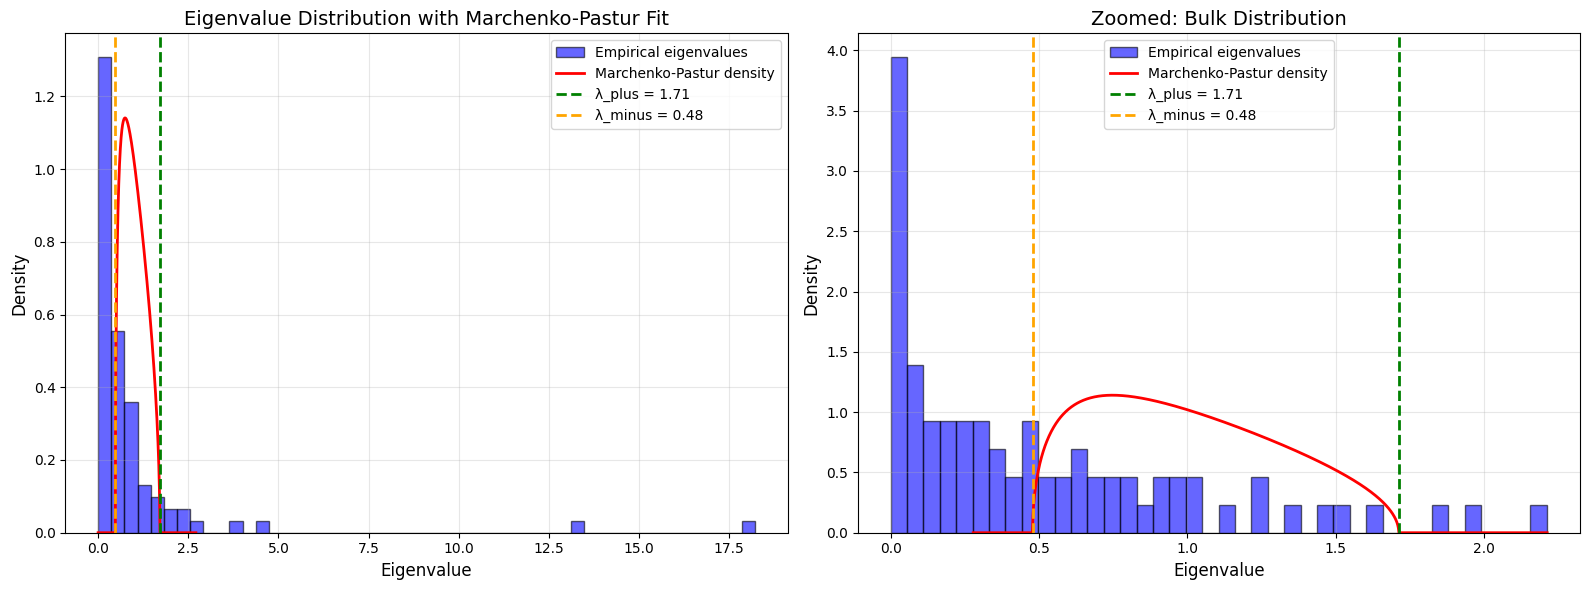

In [9]:
# Visualize Eigenvalue histogram with Marchenko-Pastur density
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full eigenvalue spectrum
ax1 = axes[0]
# Histogram of eigenvalues
ax1.hist(eigenvalues, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black', label='Empirical eigenvalues')

# Marchenko-Pastur density
x_range = np.linspace(max(0, lambda_minus - 0.5), lambda_plus + 1, 1000)
mp_density = np.array([marchenko_pastur_pdf(x, gamma) for x in x_range])

ax1.plot(x_range, mp_density, 'r-', linewidth=2, label='Marchenko-Pastur density')
ax1.axvline(lambda_plus, color='green', linestyle='--', linewidth=2, label=f'λ_plus = {lambda_plus:.2f}')
ax1.axvline(lambda_minus, color='orange', linestyle='--', linewidth=2, label=f'λ_minus = {lambda_minus:.2f}')

ax1.set_xlabel('Eigenvalue', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Eigenvalue Distribution with Marchenko-Pastur Fit', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Zoomed in on bulk
ax2 = axes[1]
# Filter eigenvalues in the bulk region
bulk_eigenvalues = eigenvalues[eigenvalues <= lambda_plus + 0.5]
ax2.hist(bulk_eigenvalues, bins=40, density=True, alpha=0.6, color='blue', edgecolor='black', label='Empirical eigenvalues')

# Matchenko-Pastur density for bulk region
x_bulk = np.linspace(max(0, lambda_minus - 0.2), lambda_plus + 0.5, 1000)
mp_bulk = np.array([marchenko_pastur_pdf(x, gamma) for x in x_bulk])

ax2.plot(x_bulk, mp_bulk, 'r-', linewidth=2, label='Marchenko-Pastur density')
ax2.axvline(lambda_plus, color='green', linestyle='--', linewidth=2, label=f'λ_plus = {lambda_plus:.2f}')
ax2.axvline(lambda_minus, color='orange', linestyle='--', linewidth=2, label=f'λ_minus = {lambda_minus:.2f}')

ax2.set_xlabel('Eigenvalue', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Zoomed: Bulk Distribution', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 4. Extract Principal Components Corresponding to Outlier Eigenvalues

### Perform **Singular Value Decomposition**

Let the standardized data matrix have SVD $$X = U \Sigma V^{T}$$

$$U \in \mathbb{R}^{m \times m} \text{ comprise the left singular vectors}$$

$$V \in \mathbb{R}^{N \times N} \text{ comprise the right singular vectors}$$

$$\Sigma = \mathrm{diag}(\sigma_1, \dots, \sigma_r, \dots, 0) \text{ comprise the singular values in descending order}$$

Then we have:

- The right singular vectors, or rows of $$V^{T}$$ as the principal components

- Since we identified 9 outlier eigenvalues, we extract the **first 9 right singular vectors**

- These singular vectors correspond to the 9 largest eigenvalues, which are exactly the outlier eigenvalues above λ<sub>+</sub>

To demonstrate this, let the covariance matrix have eigendecomposition $$S = V \Lambda V^{T}$$

Then $$X^{T}X = (U \Sigma V^{T})^{T}(U \Sigma V^{T}) = V \Sigma^{T} U^{T} U \Sigma V^{T} = V \Sigma^{2} V^T$$

so $$S = \frac{1}{N}X^{T}X = V (\frac{\Sigma^{2}}{N}) V^T$$

In [10]:
print("-" * 60)
print("Singular Value Decomposition")
print("-" * 60)

# Perform SVD on standardized data (N × m format)
# X_standardized has shape (883, 84) = (N, m)
U, S, Vt = np.linalg.svd(X_standardized, full_matrices=False)

print(f"Shape of U: {U.shape}")  # (N, m) = (883, 84)
print(f"Shape of S: {S.shape}")  # (m,) = (84,)
print(f"Shape of Vt: {Vt.shape}")  # (m, m) = (84, 84)
print(f"\nTop 5 singular values: {S[:5]}")
print(f"Sum of singular values: {S.sum():.4f}")

# For centered/standardized data: eigenvalues = (singular values)^2 / N
eigenvalues_from_svd = (S ** 2) / N
print(f"\nTop 5 eigenvalues from SVD: {eigenvalues_from_svd[:5]}")
print(f"Match with eigenvalues of covariance matrix: {np.allclose(eigenvalues, eigenvalues_from_svd)}")

# The right singular vectors (rows of Vt) are the principal components
# Vt[i,:] is the i-th principal component (eigenvector of covariance matrix)
print(f"\nRight singular vectors are principal components")
print(f"Vt[0,:] is PC1, Vt[1,:] is PC2, etc.")
print()

------------------------------------------------------------
Singular Value Decomposition
------------------------------------------------------------
Shape of U: (883, 84)
Shape of S: (84,)
Shape of Vt: (84, 84)

Top 5 singular values: [126.79514053 107.91370813  64.38229051  58.50732978  50.45612395]
Sum of singular values: 1826.5357

Top 5 eigenvalues from SVD: [18.2072567  13.18841269  4.69431408  3.87667909  2.88314886]
Match with eigenvalues of covariance matrix: True

Right singular vectors are principal components
Vt[0,:] is PC1, Vt[1,:] is PC2, etc.



### Based on the results, extract the corresponding principal components of outlier eigenvalues


In [11]:
print("-" * 60)
print("Extract Principal Components for Outlier Eigenvalues Using SVD")
print("-" * 60)

# Identify outlier eigenvalues (above MP noise edge)
# Recall from previous analysis that there's 9 of them
outlier_mask = eigenvalues > lambda_plus
outlier_indices = np.where(outlier_mask)[0]
outlier_eigenvalues = eigenvalues[outlier_mask]
n_outliers = len(outlier_eigenvalues)

print(f"\nOutlier eigenvalues and their corresponding PCs:")
for i, (idx, eig) in enumerate(zip(outlier_indices, outlier_eigenvalues)):
    var_explained = explained_variance_ratio[idx]
    print(f"  PC{idx+1}: λ = {eig:.4f} (explains {var_explained*100:.2f}% variance)")

# Since SVD orders singular values in descending order,
# the first n_outliers right singular vectors correspond to the outlier eigenvalues
# Extract first n_outliers rows of Vt and transpose to get column vectors
outlier_pcs = Vt[:n_outliers, :].T

------------------------------------------------------------
Extract Principal Components for Outlier Eigenvalues Using SVD
------------------------------------------------------------

Outlier eigenvalues and their corresponding PCs:
  PC1: λ = 18.2073 (explains 21.68% variance)
  PC2: λ = 13.1884 (explains 15.70% variance)
  PC3: λ = 4.6943 (explains 5.59% variance)
  PC4: λ = 3.8767 (explains 4.62% variance)
  PC5: λ = 2.8831 (explains 3.43% variance)
  PC6: λ = 2.3092 (explains 2.75% variance)
  PC7: λ = 2.2102 (explains 2.63% variance)
  PC8: λ = 1.9754 (explains 2.35% variance)
  PC9: λ = 1.8426 (explains 2.19% variance)


For example, this is the Principal Component corresponding to the larget outlier eigenvalue:

In [12]:
print(outlier_pcs[:,0])

[-0.04492838  0.10328673  0.1455104   0.13850691 -0.08821992  0.00427108
  0.02085861  0.02379244 -0.20662679 -0.20216798 -0.1501864  -0.14495279
 -0.20805687 -0.20734264 -0.17471901 -0.15406196  0.05015377  0.04532899
 -0.18139364  0.03444173  0.02788862 -0.14698616 -0.00657573 -0.09707414
  0.03066243 -0.01378873 -0.00162148 -0.01318333  0.04925588  0.02198847
 -0.00939009  0.10396562  0.08364576  0.08426077 -0.00214371  0.0356758
 -0.00118172  0.05019863  0.05430945  0.0422438   0.0027964  -0.11810677
 -0.10622784 -0.10879783  0.01104123 -0.12069429 -0.11733334 -0.07105602
 -0.06987581 -0.10136187 -0.03008415 -0.14301286 -0.10196043 -0.04640669
 -0.18521833 -0.14612252 -0.1937996  -0.20693108  0.09616928  0.17711371
 -0.18532618  0.11980042  0.08451139  0.13105161 -0.13380818 -0.06117239
 -0.05981043  0.09910925  0.03084937  0.14116667  0.16076965  0.11252652
 -0.13909162  0.16144021 -0.03288443 -0.01242673  0.00198597 -0.00526843
  0.05019187  0.12874529 -0.02061606 -0.15716794  0.

## 5. Projecting Data Onto Outlier Principal Components

Since we have 9 principal components corresponding to outliers, we'll explore multiple projections to understand the data from different perspectives.

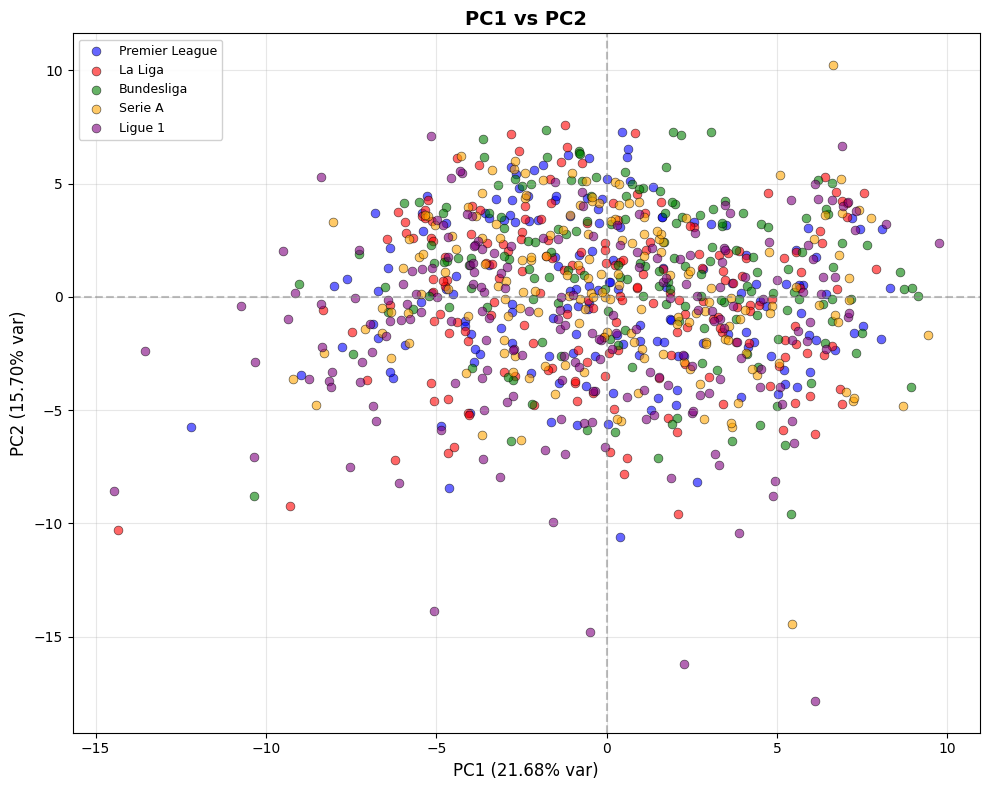

In [13]:
# PC1 vs PC2
X_signal = X_standardized @ outlier_pcs

fig, ax = plt.subplots(figsize=(10, 8))

# Colored by league
league_labels = y[:, 1].astype(int)

# Define discrete colors for each league
league_colors = {1: 'blue', 2: 'red', 3: 'green', 4: 'orange', 5: 'purple'}
league_names = {1: 'Premier League', 2: 'La Liga', 3: 'Bundesliga', 4: 'Serie A', 5: 'Ligue 1'}

for league_id, color in league_colors.items():
    mask = league_labels == league_id
    ax.scatter(X_signal[mask, 0], X_signal[mask, 1], 
                alpha=0.6, s=40, c=color, label=league_names[league_id],
                edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% var)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% var)', fontsize=12)
ax.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

- A main cluster of players are more spread horizontally along PC1 than vertically along PC2, with some outliers at the extremes.

- We do not see a clear distinction beween players from different legues.

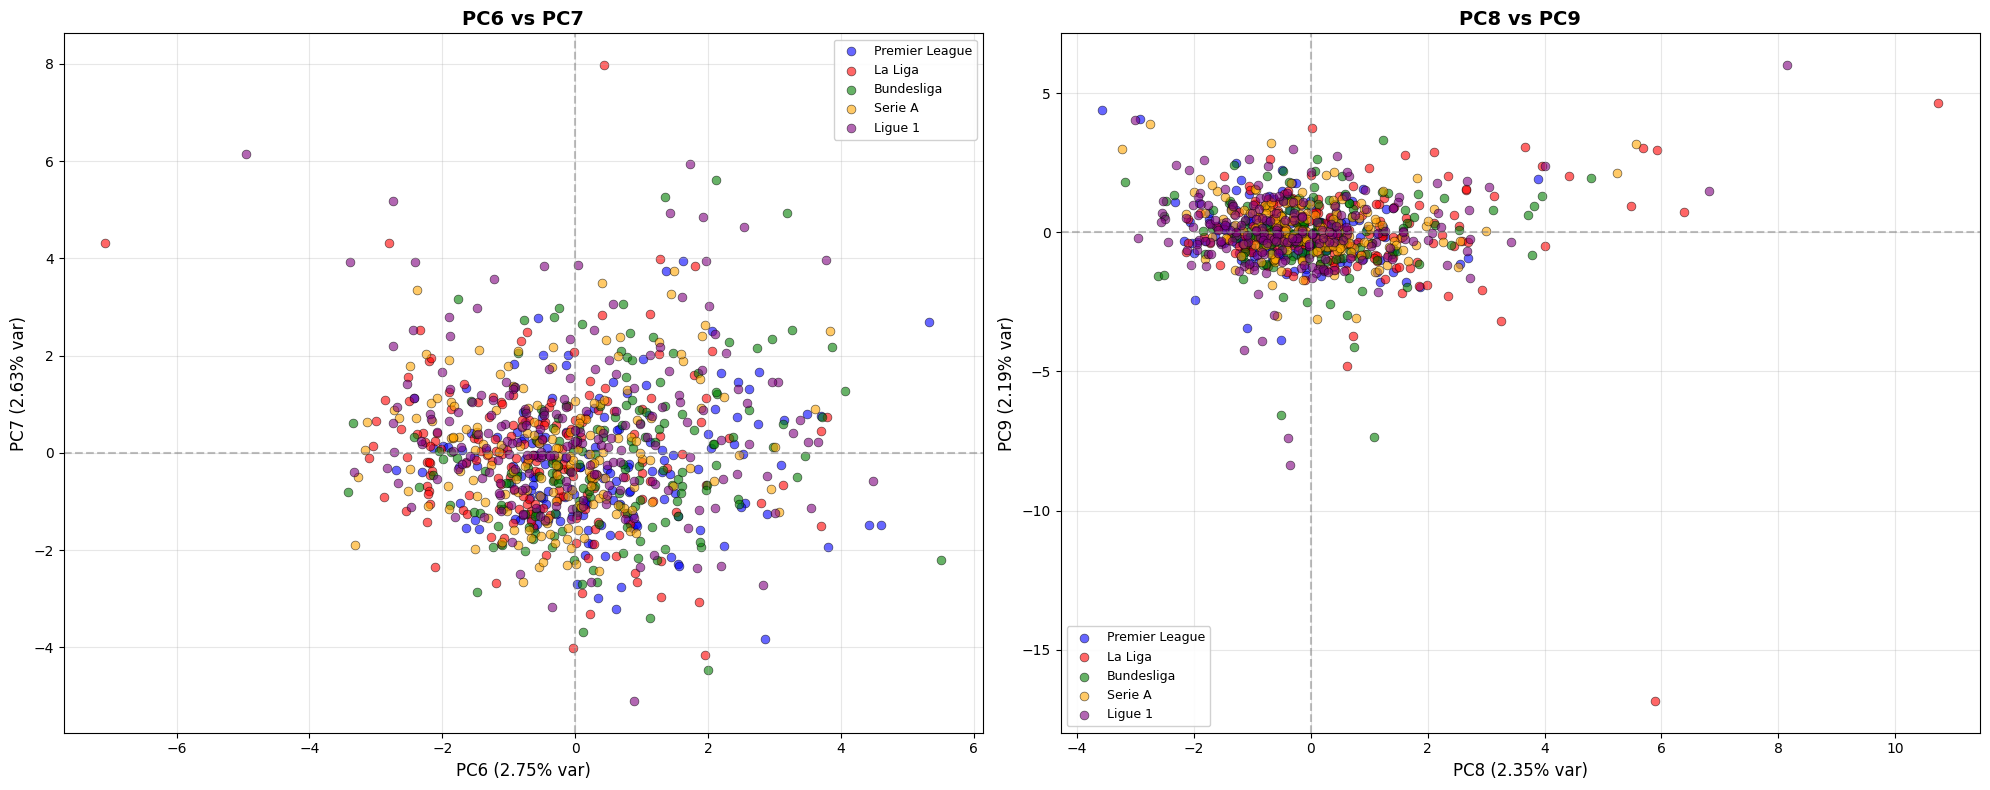

In [14]:
# PC6 vs PC7 and PC8 vs PC9
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Define discrete colors for each league
league_colors = {1: 'blue', 2: 'red', 3: 'green', 4: 'orange', 5: 'purple'}
league_names = {1: 'Premier League', 2: 'La Liga', 3: 'Bundesliga', 4: 'Serie A', 5: 'Ligue 1'}

# Left plot: PC6 vs PC7
ax1 = axes[0]
for league_id, color in league_colors.items():
    mask = league_labels == league_id
    ax1.scatter(X_signal[mask, 5], X_signal[mask, 6], 
               alpha=0.6, s=40, c=color, label=league_names[league_id],
               edgecolors='black', linewidth=0.5)

ax1.set_xlabel(f'PC6 ({explained_variance_ratio[5]*100:.2f}% var)', fontsize=12)
ax1.set_ylabel(f'PC7 ({explained_variance_ratio[6]*100:.2f}% var)', fontsize=12)
ax1.set_title('PC6 vs PC7', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.legend(loc='best', fontsize=9, framealpha=0.9)

# Right plot: PC8 vs PC9
ax2 = axes[1]
for league_id, color in league_colors.items():
    mask = league_labels == league_id
    ax2.scatter(X_signal[mask, 7], X_signal[mask, 8], 
               alpha=0.6, s=40, c=color, label=league_names[league_id],
               edgecolors='black', linewidth=0.5)

ax2.set_xlabel(f'PC8 ({explained_variance_ratio[7]*100:.2f}% var)', fontsize=12)
ax2.set_ylabel(f'PC9 ({explained_variance_ratio[8]*100:.2f}% var)', fontsize=12)
ax2.set_title('PC8 vs PC9', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='best', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

- These are the principal components corresponding to the weakest signals.

- Both projections have data highly concentrated around the origin.

- These components likely capture subtle player differences.

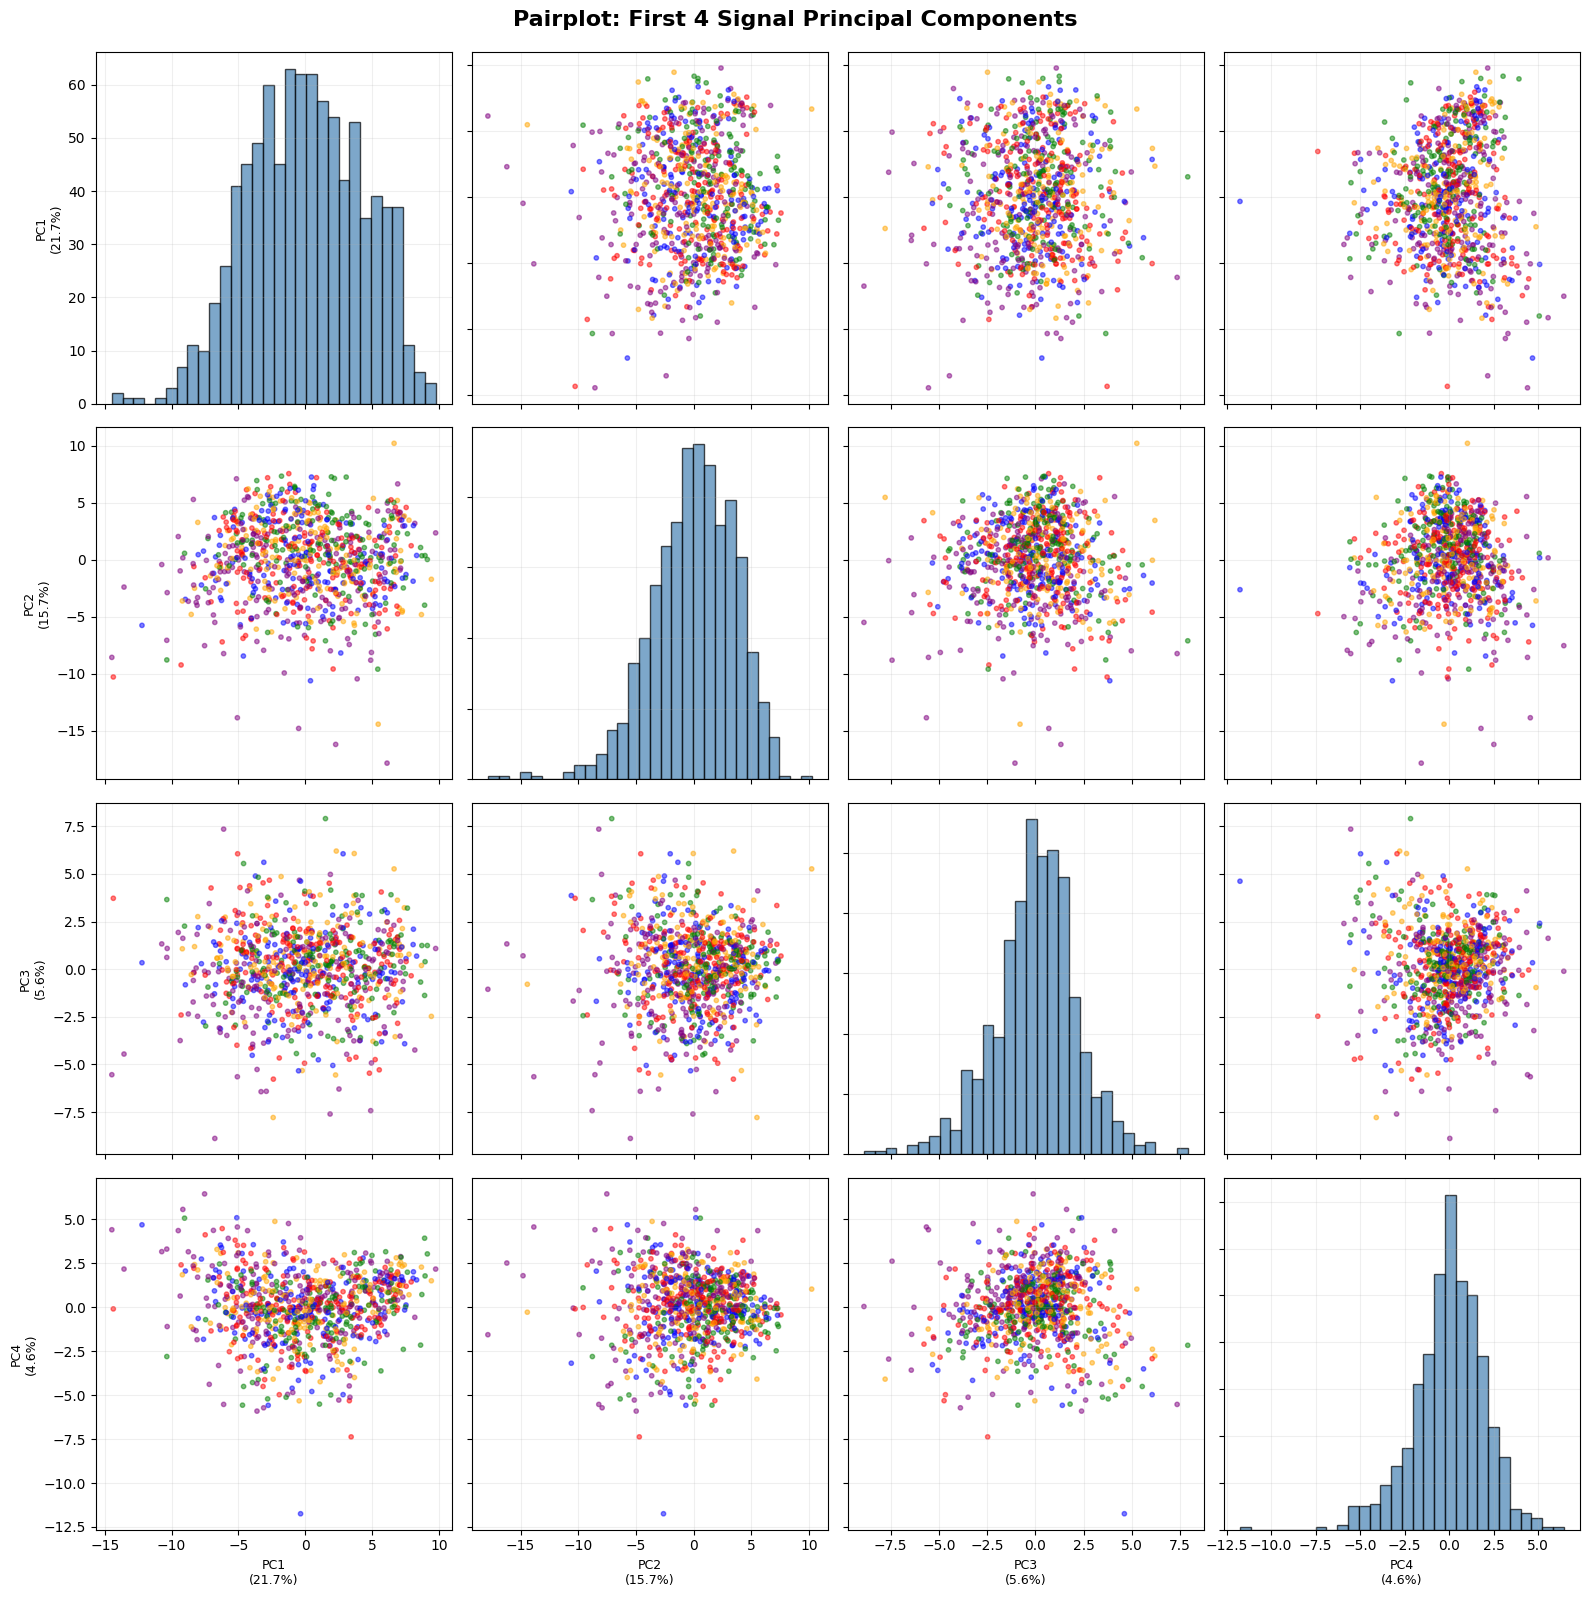

In [15]:
# Pairplot matrix for first 4 signal components
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Define discrete colors for each league
league_colors = {1: 'blue', 2: 'red', 3: 'green', 4: 'orange', 5: 'purple'}
colors_mapped = [league_colors[label] for label in league_labels]

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histograms
            ax.hist(X_signal[:, i], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=9)
        else:
            # Off-diagonal: scatter plots
            scatter = ax.scatter(X_signal[:, j], X_signal[:, i], 
                               alpha=0.5, s=10, c=colors_mapped)
        
        # Labels
        if i == 3:  # Bottom row
            ax.set_xlabel(f'PC{j+1}\n({explained_variance_ratio[j]*100:.1f}%)', fontsize=9)
        else:
            ax.set_xlabel('')
            ax.set_xticklabels([])
            
        if j == 0:  # Left column
            ax.set_ylabel(f'PC{i+1}\n({explained_variance_ratio[i]*100:.1f}%)', fontsize=9)
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        
        ax.grid(True, alpha=0.2)

plt.suptitle('Pairplot: First 4 Signal Principal Components', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


 - Pairplot reveals all pairwise relationships among the top 4 components.

 - Again, we do not see a clear clustering distinction between leagues.

 - This could suggest that player styles and abilities transcend leagues.

## 6. Analysis and Interpretation

A few main things to notice.

First, we see in section 3 that the Marchenko-Pastur Density fits poorly to our histogram of eigenvalues.

A reason for this could be due to the existence of strong correlation between the data.

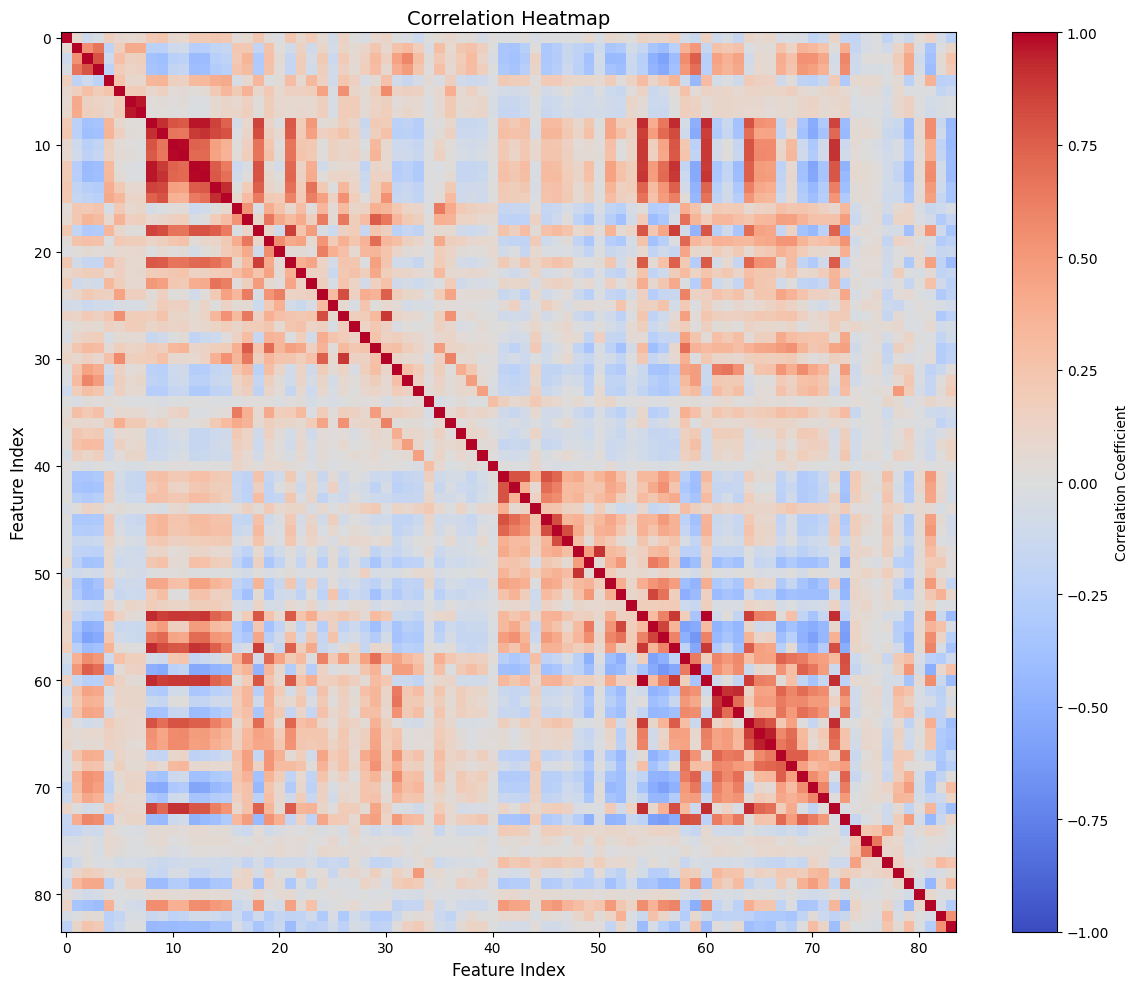

In [16]:
# Correlation heatmap
n_features_to_show = 84
corr_subset = np.corrcoef(X[:, :n_features_to_show], rowvar=False)

plt.figure(figsize=(12, 10))
plt.imshow(corr_subset, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.title(f'Correlation Heatmap', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Feature Index', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Extract most correlated feature pairs

# Get feature names
feature_names = data.drop(columns=['Player', 'Comp']).columns.tolist()

# Get upper triangle of correlation matrix (to avoid duplicates and diagonal)
upper_triangle_indices = np.triu_indices_from(corr_subset, k=1)

# Extract correlations and their indices
correlations = corr_subset[upper_triangle_indices]
feature_pairs = list(zip(upper_triangle_indices[0], upper_triangle_indices[1]))

# Sort by correlation value
sorted_indices = np.argsort(correlations)

# Get top 10 most positively correlated
print("\n10 MOST POSITIVELY CORRELATED FEATURE PAIRS:")
for i in range(1, 11):
    idx = sorted_indices[-i]
    feat1_idx, feat2_idx = feature_pairs[idx]
    corr_value = correlations[idx]
    feat1_name = feature_names[feat1_idx]
    feat2_name = feature_names[feat2_idx]
    print((feat1_name, feat2_name, f"{corr_value:.3g}"))

# Get top 10 most negatively correlated
print("\n10 MOST NEGATIVELY CORRELATED FEATURE PAIRS:")
for i in range(10):
    idx = sorted_indices[i]
    feat1_idx, feat2_idx = feature_pairs[idx]
    corr_value = correlations[idx]
    feat1_name = feature_names[feat1_idx]
    feat2_name = feature_names[feat2_idx]
    print((feat1_name, feat2_name, f"{corr_value:.3g}"))


10 MOST POSITIVELY CORRELATED FEATURE PAIRS:
('Touches', 'TouLive', '1')
('PasShoCmp', 'PasShoAtt', '0.992')
('PasMedCmp', 'PasMedAtt', '0.986')
('PasTotDist', 'PasMedCmp', '0.967')
('ShoPK', 'PKatt', '0.964')
('PasTotDist', 'PasMedAtt', '0.962')
('CarTotDist', 'CarPrgDist', '0.95')
('PasTotDist', 'TouLive', '0.928')
('PasTotDist', 'Touches', '0.928')
('ToAtt', 'ToTkl', '0.926')

10 MOST NEGATIVELY CORRELATED FEATURE PAIRS:
('TouDef3rd', 'TouAttPen', '-0.632')
('TouDef3rd', 'RecProg', '-0.608')
('TouDef3rd', 'CarMis', '-0.582')
('TouDefPen', 'RecProg', '-0.58')
('TouDefPen', 'TouAtt3rd', '-0.574')
('Shots', 'TouDef3rd', '-0.571')
('PasMedCmp', 'CarMis', '-0.549')
('PasMedAtt', 'CarMis', '-0.545')
('TouMid3rd', 'TouAttPen', '-0.543')
('PasMedCmp', 'TouAttPen', '-0.532')


From above, it seems that there's a quite a few columns that are highly positively correlated.

Correlation in the neative direction is less intense.

Poor fit can also be due to sparse data.

In [18]:
# Proportion of zero values
sparsity = (X == 0).sum() / X.size
print(f"Sparsity: {sparsity:.2%}")

# Sparsity for each feature (column)
feature_sparsity = (X == 0).sum(axis=0) / X.shape[0]
print(f"Features with >65% zeros: {(feature_sparsity > 0.65).sum()}")

# Features with very low variance
feature_variance = np.var(X, axis=0)
low_variance_features = (feature_variance < 0.01).sum()
print(f"Features with near-zero variance: {low_variance_features}")

Sparsity: 21.34%
Features with >65% zeros: 12
Features with near-zero variance: 12


Second, although we cannot see clear patterns holistically in the projected data, we can still say something when we view them seperately.

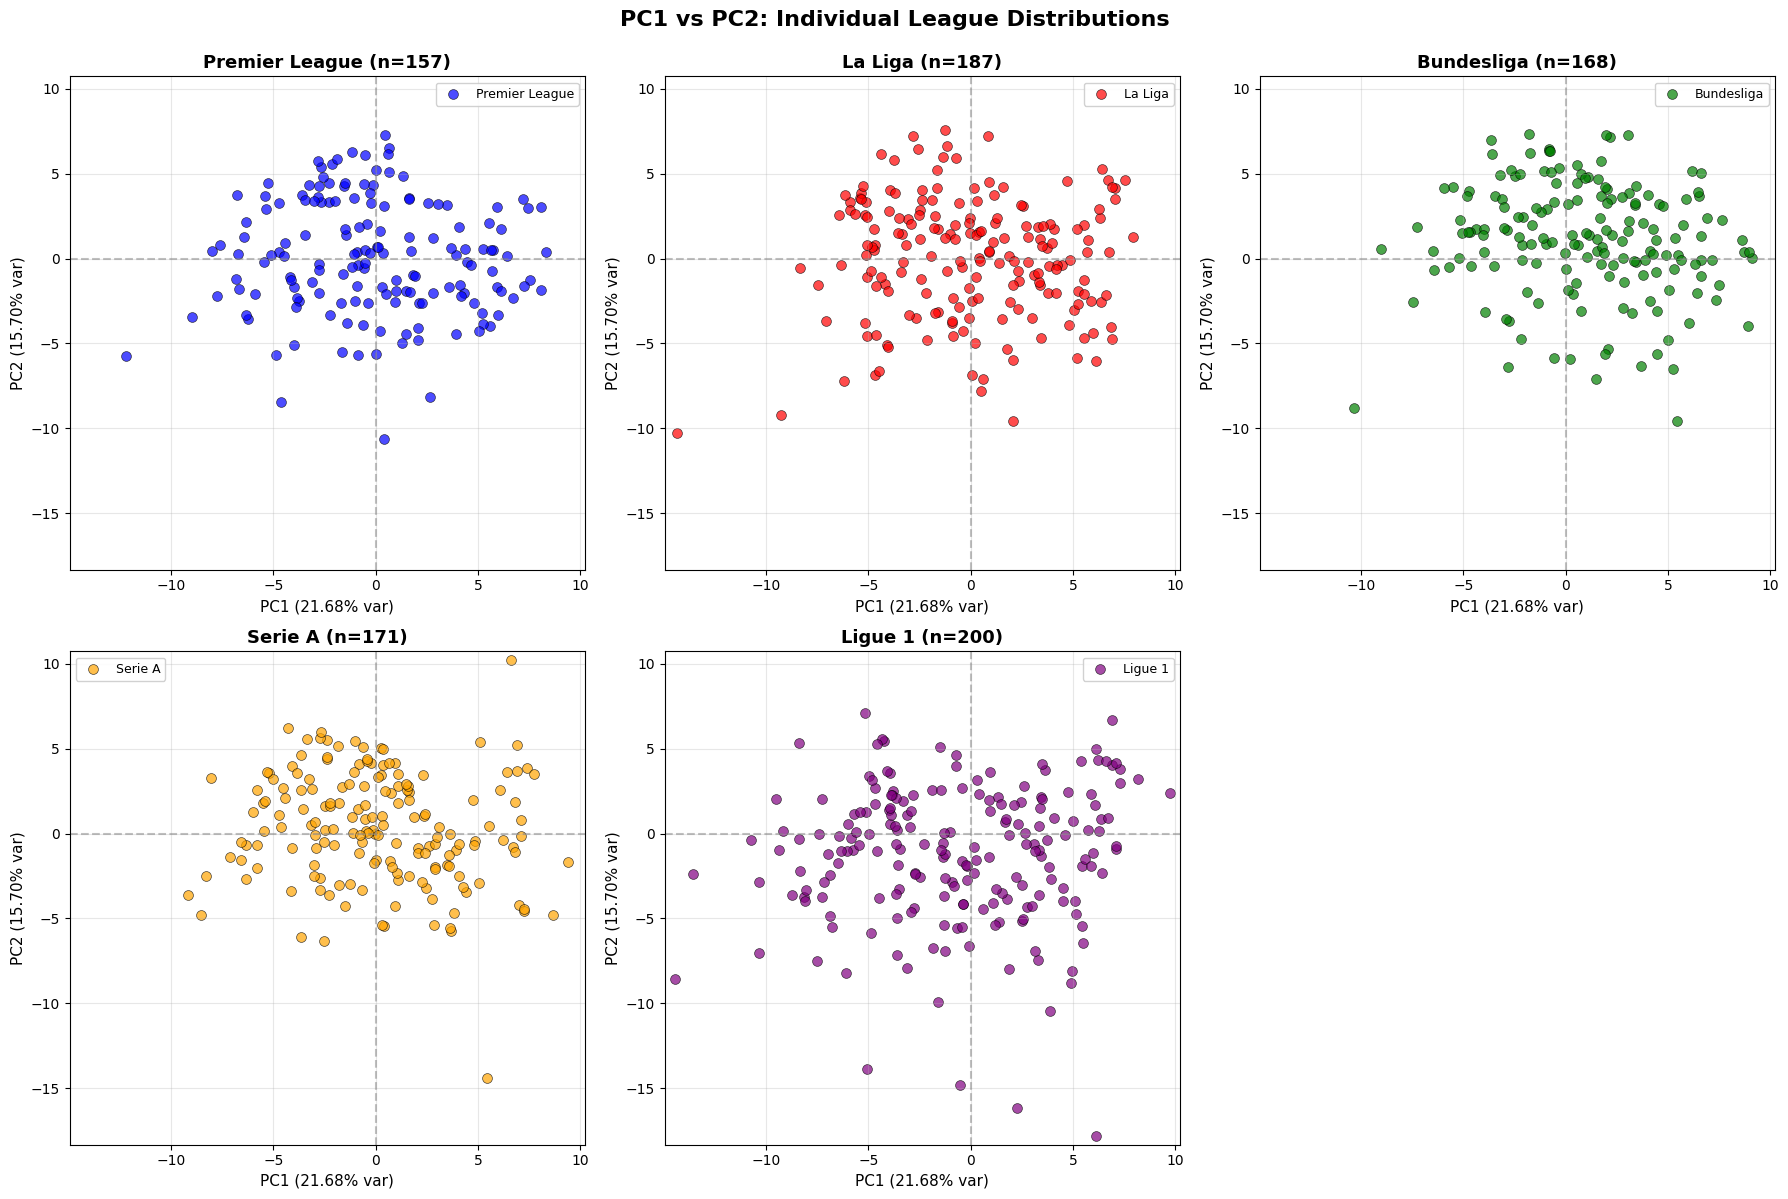

In [19]:
# PC1 vs PC2 with League Subplots

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# League details
leagues = [
    (1, 'blue', 'Premier League'),
    (2, 'red', 'La Liga'),
    (3, 'green', 'Bundesliga'),
    (4, 'orange', 'Serie A'),
    (5, 'purple', 'Ligue 1')
]

for idx, (league_id, color, league_name) in enumerate(leagues):
    ax = axes[idx]
    mask = league_labels == league_id
    
    ax.scatter(X_signal[mask, 0], X_signal[mask, 1], 
               alpha=0.7, s=50, c=color, label=league_name,
               edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% var)', fontsize=11)
    ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% var)', fontsize=11)
    ax.set_title(f'{league_name} (n={mask.sum()})', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    
    # Keep axis limits consistent across all subplots
    ax.set_xlim(X_signal[:, 0].min() - 0.5, X_signal[:, 0].max() + 0.5)
    ax.set_ylim(X_signal[:, 1].min() - 0.5, X_signal[:, 1].max() + 0.5)

# Remove the 6th subplot (bottom right)
fig.delaxes(axes[5])

plt.suptitle('PC1 vs PC2: Individual League Distributions', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

It became much clearer now that the players in Ligue 1 are more spread out vertically, and that players in Serie A are (relatively) more spread out horizontally.

The spread of players in the Premeir League, La Liga, and Bundesliga look quite similar and even. There are also similar outliers skewed towards the bottom left direction.

Third, we can analyze the loadings of our outlier principal components. This shows which original features contribute most to each signal PC.

In [20]:
# Get feature names for analysis
feature_names = data.drop(columns=['Player', 'Comp']).columns.tolist()
n_top_features = 5

In [21]:
# PC1 Loadings
i, pc_idx = 0, outlier_indices[0]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC2 Loadings
i, pc_idx = 1, outlier_indices[1]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC3 Loadings
i, pc_idx = 2, outlier_indices[2]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

PC1 (λ=18.2073, 21.68% var):
  Top 5 contributing features:
    1. PasMedCmp           : -0.2081
    2. PasMedAtt           : -0.2073
    3. TouMid3rd           : -0.2069
    4. PasTotDist          : -0.2066
    5. PasTotPrgDist       : -0.2022

PC2 (λ=13.1884, 15.70% var):
  Top 5 contributing features:
    1. TouAtt3rd           : -0.2235
    2. CarTotDist          : -0.2120
    3. CarPrgDist          : -0.2082
    4. ScaPassLive         : -0.2048
    5. Car3rd              : -0.2021

PC3 (λ=4.6943, 5.59% var):
  Top 5 contributing features:
    1. Tkl                 : -0.2812
    2. TklDriAtt           : -0.2543
    3. TklDri              : -0.2540
    4. BlkPass             : -0.2192
    5. TklMid3rd           : -0.2087


In [22]:
# PC4 Loadings
i, pc_idx = 3, outlier_indices[3]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC5 Loadings
i, pc_idx = 4, outlier_indices[4]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC6 Loadings
i, pc_idx = 5, outlier_indices[5]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

PC4 (λ=3.8767, 4.62% var):
  Top 5 contributing features:
    1. PasCrs              : -0.3107
    2. ScaPassDead         : -0.3033
    3. CK                  : -0.2911
    4. GcaPassDead         : -0.2326
    5. ShoFK               : -0.2034

PC5 (λ=2.8831, 3.43% var):
  Top 5 contributing features:
    1. TI                  : -0.3225
    2. CrsPA               : -0.2499
    3. PKatt               : +0.2236
    4. ShoPK               : +0.2187
    5. Goals               : +0.2127

PC6 (λ=2.3092, 2.75% var):
  Top 5 contributing features:
    1. TI                  : +0.2613
    2. ShoDist             : -0.2577
    3. AerWon              : +0.2497
    4. Clr                 : +0.2324
    5. Fld                 : -0.2275


In [23]:
# PC7 Loadings
i, pc_idx = 6, outlier_indices[6]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC8 Loadings
i, pc_idx = 7, outlier_indices[7]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

print()

# PC9 Loadings
i, pc_idx = 8, outlier_indices[8]
print(f"PC{pc_idx+1} (λ={outlier_eigenvalues[i]:.4f}, {explained_variance_ratio[pc_idx]*100:.2f}% var):")

loadings = outlier_pcs[:, i]
abs_loadings = np.abs(loadings)
top_indices = np.argsort(abs_loadings)[-n_top_features:][::-1]

print(f"  Top {n_top_features} contributing features:")
for rank, feat_idx in enumerate(top_indices, 1):
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    loading = loadings[feat_idx]
    print(f"    {rank}. {feat_name:20s}: {loading:+.4f}")

PC7 (λ=2.2102, 2.63% var):
  Top 5 contributing features:
    1. ShoPK               : +0.2875
    2. PKatt               : +0.2841
    3. TouDefPen           : +0.2296
    4. Clr                 : +0.2123
    5. ScaPassLive         : -0.2058

PC8 (λ=1.9754, 2.35% var):
  Top 5 contributing features:
    1. CrdR                : +0.3924
    2. 2CrdY               : +0.3920
    3. CrdY                : +0.3657
    4. Fls                 : +0.2289
    5. Min                 : -0.2140

PC9 (λ=1.8426, 2.19% var):
  Top 5 contributing features:
    1. ShoPK               : -0.4861
    2. PKatt               : -0.4697
    3. 2CrdY               : +0.2237
    4. CrdR                : +0.2231
    5. ScaSh               : +0.2161


It's not surprising that features related to passing, touches, and carries contribute the most to the top 3 signal PCs.

They represent some of the most important qualities required to become a good midfielder.

Finally, it would be interesting to look at where top players are located in the PC spaces.

In [24]:
players_to_examine = [
    'Luka Modri?', 'Toni Kroos', 'Casemiro', 
    'Fabinho', 'Christian Eriksen', 'Frenkie de Jong', 
    'Kevin De Bruyne', 'Bernardo Silva', 'Declan Rice', 
    'Rodri', 'Bruno Fernandes', 'Jude Bellingham', 'Paulo Dybala',
    'Gavi', 'Pedri', 'Martin Ødegaard', 'Vitinha', 'Hakan Çalhanoðlu',
    'Dominik Szoboszlai', 'Joshua Kimmich', 'Alexis Mac Allister', 
    'James Maddison', 'Mason Mount', 'Thomas Müller', 
    'Thomas Partey', 'Rúben Neves', 'Nicolò Barella',
    'David Silva', 'Granit Xhaka', 'Martin Ødegaard', 'Vitinha',
    'Thiago Alcántara'
    ]

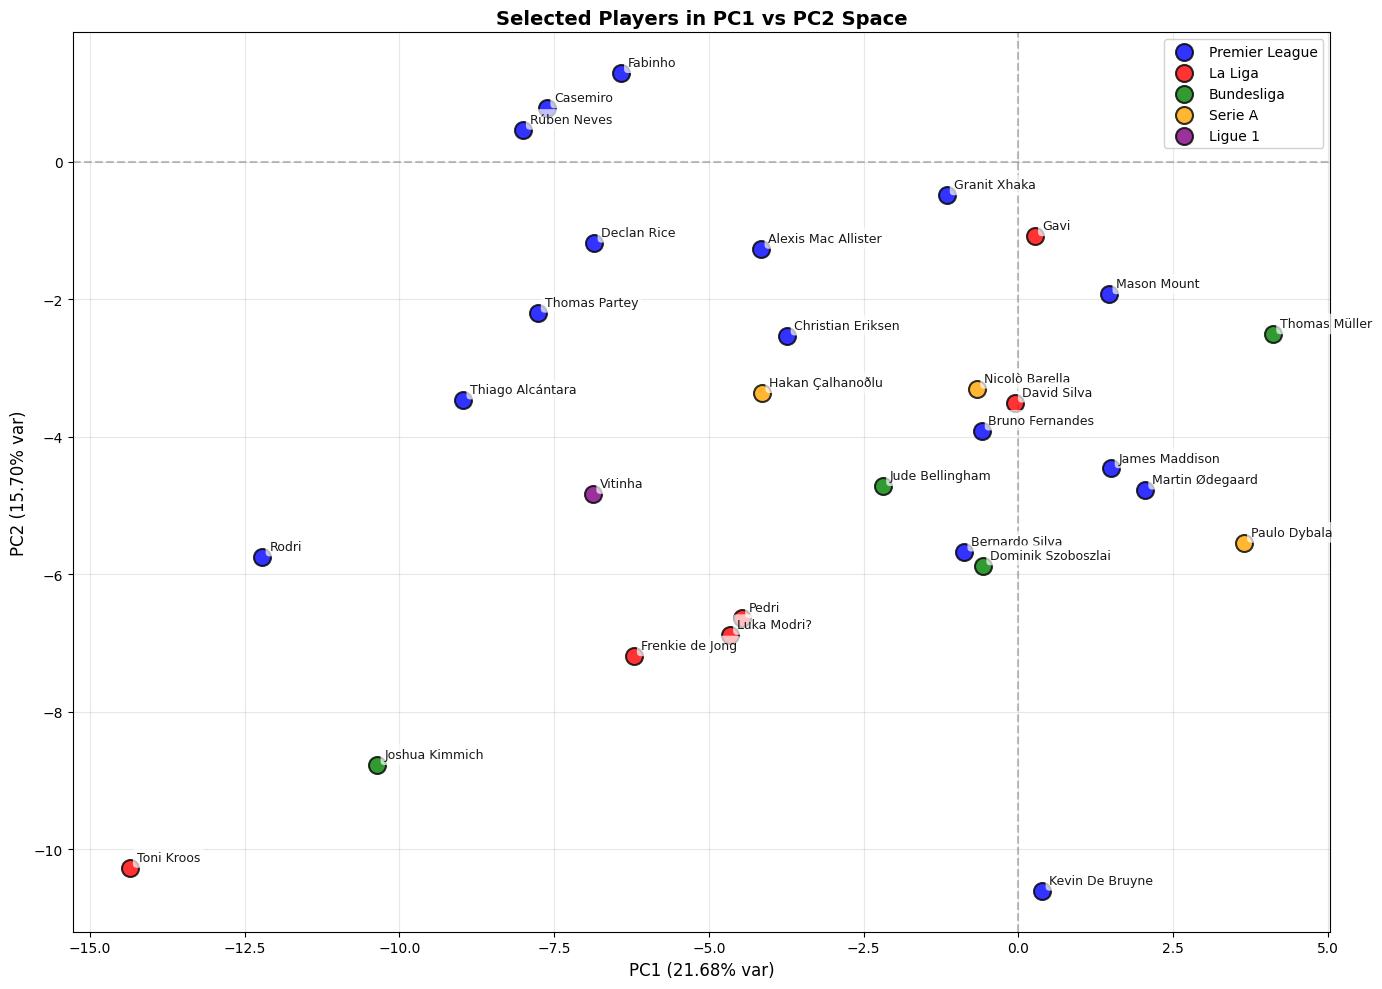

In [25]:
# Filter data to only include players of interest
player_names = y[:, 0] 
league_labels = y[:, 1].astype(int)

# Find indices of players in the examination list
player_indices = [i for i, name in enumerate(player_names) if name in players_to_examine]

# Filter the data
X_signal_filtered = X_signal[player_indices]
player_names_filtered = player_names[player_indices]
league_labels_filtered = league_labels[player_indices]

# Visualize specific players in PC1 vs PC2 space
fig, ax = plt.subplots(figsize=(14, 10))

# Same colors for each league
league_colors = {1: 'blue', 2: 'red', 3: 'green', 4: 'orange', 5: 'purple'}
league_names = {1: 'Premier League', 2: 'La Liga', 3: 'Bundesliga', 4: 'Serie A', 5: 'Ligue 1'}

# Plot each player colored by their league
for league_id, color in league_colors.items():
    mask = league_labels_filtered == league_id
    if mask.any():
        ax.scatter(X_signal_filtered[mask, 0], X_signal_filtered[mask, 1], 
                  alpha=0.8, s=150, c=color, label=league_names[league_id],
                  edgecolors='black', linewidth=1.5, zorder=3)

# Add labels for each player
for i, player_name in enumerate(player_names_filtered):
    ax.annotate(player_name, 
                (X_signal_filtered[i, 0], X_signal_filtered[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% var)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% var)', fontsize=12)
ax.set_title('Selected Players in PC1 vs PC2 Space', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

This result allows for a more precise interpretation of what the PCs represent.

It seems that PC1 is an indicator for attack vs defense. If a player plays more defensivly, they will be located towards the left, vice versa for players towards the right.

Players like Rodri, Rice, Kimmich and Casemiro are all well-kown defensive midfielders, while players like De Bruyne and Muller are known for their ability to initiate attacks.

It's unclear what PC2 indicates exactly, but notice that players De Bruyne, and Toni Kroos are all significantly skewed towards the negative direction horizontally.



## 7. Appendix

Column Index:
 
 - Player : Player's name

 - Nation : Player's nation

 - Pos : Position

 - Squad : Squad’s name

 - Comp : League that squat occupies

 - Age : Player's age

 - Born : Year of birth

 - MP : Matches played

 - Starts : Matches started

 - Min : Minutes played

 - 90s : Minutes played divided by 90

 - Goals : Goals scored or allowed

 - Shots : Shots total (Does not include penalty kicks)

 - SoT : Shots on target (Does not include penalty kicks)

 - SoT% : Shots on target percentage (Does not include penalty kicks)

 - G/Sh : Goals per shot

 - G/SoT : Goals per shot on target (Does not include penalty kicks)

 - ShoDist : Average distance, in yards, from goal of all shots taken (Does not include penalty kicks)

 - ShoFK : Shots from free kicks

 - ShoPK : Penalty kicks made

 - PKatt : Penalty kicks attempted

 - PasTotCmp : Passes completed

 - PasTotAtt : Passes attempted

 - PasTotCmp% : Pass completion percentage

 - PasTotDist : Total distance, in yards, that completed passes have traveled in any direction

 - PasTotPrgDist : Total distance, in yards, that completed passes have traveled towards the opponent's goal

 - PasShoCmp : Passes completed (Passes between 5 and 15 yards)

 - PasShoAtt : Passes attempted (Passes between 5 and 15 yards)

 - PasShoCmp% : Pass completion percentage (Passes between 5 and 15 yards)

 - PasMedCmp : Passes completed (Passes between 15 and 30 yards)

 - PasMedAtt : Passes attempted (Passes between 15 and 30 yards)

 - PasMedCmp% : Pass completion percentage (Passes between 15 and 30 yards)

 - PasLonCmp : Passes completed (Passes longer than 30 yards)

 - PasLonAtt : Passes attempted (Passes longer than 30 yards)

 - PasLonCmp% : Pass completion percentage (Passes longer than 30 yards)

 - Assists : Assists

 - PasAss : Passes that directly lead to a shot (assisted shots)

 - Pas3rd : Completed passes that enter the 1/3 of the pitch closest to the goal

 - PPA : Completed passes into the 18-yard box

 - CrsPA : Completed crosses into the 18-yard box

 - PasProg : Completed passes that move the ball towards the opponent's goal at least 10 yards from its furthest point in the last six passes, or any completed pass into the penalty area

 - PasAtt : Passes attempted

 - PasLive : Live-ball passes

 - PasDead : Dead-ball passes

 - PasFK : Passes attempted from free kicks

 - TB : Completed pass sent between back defenders into open space

 - Sw : Passes that travel more than 40 yards of the width of the pitch

 - PasCrs : Crosses

 - TI : Throw-Ins taken

 - CK : Corner kicks

 - CkIn : Inswinging corner kicks

 - CkOut : Outswinging corner kicks

 - CkStr : Straight corner kicks

 - PasCmp : Passes completed

 - PasOff : Pass offsides

 - PasBlocks : Pass blocked

 - SCA : Shot-creating actions

 - ScaPassLive : Completed live-ball passes that lead to a shot attempt

 - ScaPassDead : Completed dead-ball passes that lead to a shot attempt

 - ScaDrib : Successful dribbles that lead to a shot attempt

 - ScaSh : Shots that lead to another shot attempt

 - ScaFld : Fouls drawn that lead to a shot attempt

 - ScaDef : Defensive actions that lead to a shot attempt

 - GCA : Goal-creating actions

 - GcaPassLive : Completed live-ball passes that lead to a goal

 - GcaPassDead : Completed dead-ball passes that lead to a goal

 - GcaDrib : Successful dribbles that lead to a goal

 - GcaSh : Shots that lead to another goal-scoring shot

 - GcaFld : Fouls drawn that lead to a goal

 - GcaDef : Defensive actions that lead to a goal

 - Tkl : Number of players tackled

 - TklWon : Tackles in which the tackler's team won possession of the ball

 - TklDef3rd : Tackles in defensive 1/3

 - TklMid3rd : Tackles in middle 1/3

 - TklAtt3rd : Tackles in attacking 1/3

 - TklDri : Number of dribblers tackled

 - TklDriAtt : Number of times dribbled past plus number of tackles

 - TklDri% : Percentage of dribblers tackled

 - TklDriPast : Number of times dribbled past by an opposing player

 - Blocks : Number of times blocking the ball by standing in its path

 - BlkSh : Number of times blocking a shot by standing in its path

 - BlkPass : Number of times blocking a pass by standing in its path

 - Int : Interceptions

 - Tkl+Int : Number of players tackled plus number of interceptions

 - Clr : Clearances

 - Err : Mistakes leading to an opponent's shot

 - Touches : Number of times a player touched the ball. Note: Receiving a pass, then dribbling, then sending a pass counts as one touch

 - TouDefPen : Touches in defensive penalty area

 - TouDef3rd : Touches in defensive 1/3

 - TouMid3rd : Touches in middle 1/3

 - TouAtt3rd : Touches in attacking 1/3

 - TouAttPen : Touches in attacking penalty area

 - TouLive : Live-ball touches. Does not include corner kicks, free kicks, throw-ins, kick-offs, goal kicks or penalty kicks.

 - ToAtt : Number of attempts to take on defenders while dribbling

 - ToSuc : Number of defenders taken on successfully, by dribbling past them

 - ToSuc% : Percentage of take-ons Completed Successfully

 - ToTkl : Number of times tackled by a defender during a take-on attempt

 - ToTkl% : Percentage of time tackled by a defender during a take-on attempt

 - Carries : Number of times the player controlled the ball with their feet

 - CarTotDist : Total distance, in yards, a player moved the ball while controlling it with their feet, in any direction

 - CarPrgDist : Total distance, in yards, a player moved the ball while controlling it with their feet towards the opponent's goal

 - CarProg : Carries that move the ball towards the opponent's goal at least 5 yards, or any carry into the penalty area

 - Car3rd : Carries that enter the 1/3 of the pitch closest to the goal

 - CPA : Carries into the 18-yard box

 - CarMis : Number of times a player failed when attempting to gain control of a ball

 - CarDis : Number of times a player loses control of the ball after being tackled by an opposing player

 - Rec : Number of times a player successfully received a pass

 - RecProg : Recieved passes that move the ball towards the opponent's goal at least 10 yards from its furthest point in the last six passes, or any completed pass into the penalty area

 - CrdY : Yellow cards

 - CrdR : Red cards

 - 2CrdY : Second yellow card

 - Fls : Fouls committed

 - Fld : Fouls drawn

 - Off : Offsides

 - Crs : Crosses

 - TklW : Tackles in which the tackler's team won possession of the ball

 - PKwon : Penalty kicks won

 - PKcon : Penalty kicks conceded

 - OG : Own goals

 - Recov : Number of loose balls recovered

 - AerWon : Aerials won

 - AerLost : Aerials lost

 - AerWon% : Percentage of aerials won